# __Hands-on with TensorFlow: Part B__

- In this demo, let's see how to implement ensemble techniques using Keras and sklearn.

## Step 1: Import the required libraries and load the dataset

- Import necessary libraries from Sklearn, TensorFlow, and Keras.
- Load the dataset using sklearn's make_moons function.
- Define X and y and split the dataset into training and testing sets using the train_test_split function.

In [1]:
!pip install tensorflow==2.17.0 scikeras==0.13.0 keras==3.2.0
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.5.2

Defaulting to user installation because normal site-packages is not writeable
Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_learn-1.5.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.3 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-privacy 0.8.11 requires dp-accounting==0.4.3, but you have dp-accounting 0.4.1 which is incompatible.
tensorflow-privacy 0.8.11 requires tensorflow-probability~=0.20.0, but you have tensorflow-probability 0.15.0 which is incompatible.
tf-models-official 2.13.2 requires tensorflow~=2.13.0, but you have tensorflow 2.17.0

In [13]:
!pip install -U tensorflow==2.13.0 \
  tensorflow-privacy==0.8.11 \
  tensorflow-probability==0.20.1 \
  tf-models-official==2.13.2 \
  dp-accounting==0.4.3 \
  scikeras==0.13.0 \
  jax==0.4.35 \
  jaxlib==0.4.35 \
  scipy==1.13.1

Defaulting to user installation because normal site-packages is not writeable
INFO: pip is looking at multiple versions of scikeras to determine which version is compatible with other requirements. This could take a while.
  Using cached scikeras-0.13.0-py3-none-any.whl.metadata (3.1 kB)


ERROR: Cannot install scikeras==0.13.0 and tensorflow==2.13.0 because these package versions have conflicting dependencies.

The conflict is caused by:
    tensorflow 2.13.0 depends on keras<2.14 and >=2.13.1
    scikeras 0.13.0 depends on keras>=3.2.0
    tensorflow 2.13.0 depends on keras<2.14 and >=2.13.1
    scikeras 0.13.0 depends on keras>=3.2.0

To fix this you could try to:
1. loosen the range of package versions you've specified
2. remove package versions to allow pip to attempt to solve the dependency conflict

ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


In [2]:
import os

# Disable oneDNN optimizations to avoid potential minor numerical differences caused by floating-point round-off errors.
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

In [3]:
# Import necessary libraries from Sklearn, TensorFlow, and Keras
import sklearn
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load the dataset using sklearn's make_moons function
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

__Observation:__
- The necessary libraries and modules have been downloaded.

## Step 2: Define classifiers

- Define Logistic Regression, Random Forest, Support Vector Machine, and Keras Neural Network classifiers.


In [4]:
# Define Logistic Regression, Random Forest, and Support Vector Machine classifiers
log_clf = LogisticRegression(solver="lbfgs", random_state=42)
rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
svm_clf = SVC(gamma="scale", random_state=42,probability=True)


- Import Sequential and Dense modules from the TensorFlow library to create a neural network.


In [6]:
# Import Sequential and Dense modules from the TensorFlow library to create a neural network

import os
from scikeras.wrappers import KerasClassifier
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense, Input

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Define the function to build a neural network
def build_nn():
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(50, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='Adam',
        loss='binary_crossentropy',
        metrics=['accuracy'])
    return model



2025-10-08 11:56:20.018736: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-08 11:56:20.034109: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-08 11:56:20.038582: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-08 11:56:20.050704: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-08 11:56:25.847847: W ten

In [5]:
!pip install "scipy<1.14"

Defaulting to user installation because normal site-packages is not writeable


- Now, let's wrap scikit learn and build a neural network with 500 epochs with the Keras classifier.

In [7]:
keras_clf = KerasClassifier(model=build_nn, epochs=500, verbose=False)

__Observation:__
- Scikit learn is wrapped.

In [8]:
keras_clf._estimator_type = "classifier"

## Step 3: Create the voting classifier

- Combine the classifiers using sklearn's VotingClassifier with soft voting.


In [9]:
# Combine the classifiers using sklearn's VotingClassifier with soft voting
voting = VotingClassifier(
             estimators=[('lr', log_clf),
                         ('rf', rnd_clf),
                         ('svc', svm_clf),
                         ('keras',keras_clf)],
             voting='soft',
             flatten_transform=True)

In [10]:
from sklearn.ensemble import StackingClassifier

estimators = [('lr', log_clf),
              ('rf', rnd_clf),
              ('svc', svm_clf),
              ('nn', keras_clf)
             ]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=log_clf,   # Logistic  as the final meta-learner
    passthrough=True
)

- The classifiers are combined with soft voting.

## Step 4: Train and evaluate the classifiers

- Train the voting classifier and each individual classifier.
- Make predictions on the test set and calculate the accuracy for each classifier.


In [11]:
models = {
    "Logistic Regression": log_clf,
    "Random Forest": rnd_clf,
    "SVC": svm_clf,
    "Neural Network": keras_clf,
    "Stacking Classifier": stacking_clf
}

for name, clf in models.items():
    clf.fit(X_train, y_train)

2025-10-08 11:57:15.545415: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


- Consider voting with VotingClassifier and estimator.
- The first is LogisticRegression, the second is RandomForest, the third is SVM, the fourth is KerasClassifier, and the fifth is VotingClassifier.

In [12]:
from sklearn.metrics import accuracy_score

print("Model Evaluation")
for name, clf in models.items():
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}: Test Accuracy = {acc:.3f}")

Model Evaluation
Logistic Regression: Test Accuracy = 0.864
Random Forest: Test Accuracy = 0.896
SVC: Test Accuracy = 0.896
Neural Network: Test Accuracy = 0.880
Stacking Classifier: Test Accuracy = 0.912


__Observation:__

- As shown above, the accuracy for each classifier models can be seen.

**Visualization of Decision Boundaries**

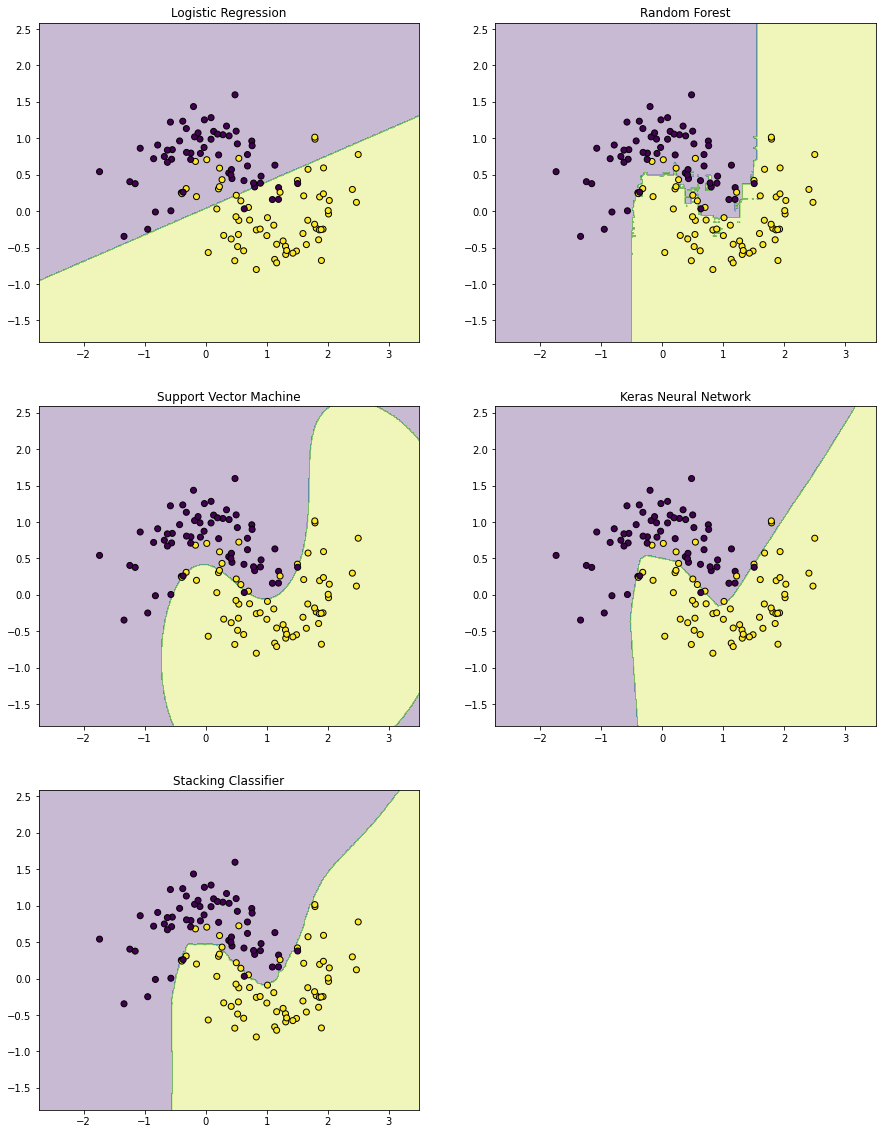

In [13]:
# Function to plot decision boundaries
def plot_decision_boundary(clf, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', marker='o')
    ax.set_title(title)

# Plot decision boundaries for each classifier
fig, axes = plt.subplots(3, 2, figsize=(15, 20))

plot_decision_boundary(log_clf, X_test, y_test, axes[0, 0], "Logistic Regression")
plot_decision_boundary(rnd_clf, X_test, y_test, axes[0, 1], "Random Forest")
plot_decision_boundary(svm_clf, X_test, y_test, axes[1, 0], "Support Vector Machine")
plot_decision_boundary(keras_clf, X_test, y_test, axes[1, 1], "Keras Neural Network")
plot_decision_boundary(stacking_clf, X_test, y_test, axes[2, 0], "Stacking Classifier")

# Hide empty subplot
axes[2, 1].axis('off')

plt.show()

**Observation:**

The decision boundaries for each classifier are visualized, showing how each model classifies the data.